In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
np.random.seed(4)

In [3]:
class MyBuffonError(Exception):
    'Длина иголок больше расстояния между линиями'
    pass

In [4]:
def needle_throw(n=1000000, # количество бросков
                 width=1.0, # расстояние между лиинями
                 needle=0.5 # длина иголки
                ) -> float:
    '''
    метод Карла Бюффон: бросание иглы
    отношение числа иголок, которые пересекли линии, к общему числу
    даст число, похожее на пи
    '''

    if needle > width:
        raise MyBuffonError(f'Длина иголок {needle:.1f} больше расстояния между линиями {width:.1f}')
    
    num_hits = 0
    num_misses = 0

    x_lo = 0.0; x_hi = 3.0
    y_lo = 0.0; y_hi = 4.0

    for i in range(n):
      x = (x_hi - x_lo) * np.random.random() + x_lo
      y = (y_hi - y_lo) * np.random.random() + y_lo
    
      angle = np.radians(360.0 * np.random.random()) 
     
      xx = x + needle * np.cos(angle)   
      yy = y + needle * np.sin(angle)
      
      if xx < x:
        (x, xx) = (xx, x)
        (y, yy) = (yy, y)
    
      if (x < 0.0 and xx > 0.0) or (x < 1.0 and xx > 1.0) or (x < 2.0 and xx > 2.0) or (x < 3.0 and xx > 3.0):
            num_hits += 1
    
      else:
        num_misses += 1
    
    pr = num_hits / (num_hits + num_misses)
    return 2 * needle / (pr * width)

In [5]:
def circle_throw(n=1000000 # количество бросков
                ) -> float:
    '''
    определение числа пи методом Монте-Карло
    случайным образом бросаем точку в квадрат
    вероятность того, что точка упадет внутрь круга 
    равна отношению площадей, следовательно, числу пи
    '''
    i = 0
    count = 0

    while i < n:
        x = np.random.random()
        y = np.random.random()

        if (pow(x, 2) + pow(y, 2)) < 1:
            count += 1

        i += 1
    return 4 * (count / n)

In [6]:
print(f'Рассчитанное значение числа Пи: {needle_throw(n=100, width = 1.0, needle = 1.5):0.4f}')

MyBuffonError: Длина иголок 1.5 больше расстояния между линиями 1.0

In [7]:
print(f'Рассчитанное значение числа Пи: {needle_throw():0.4f}')

Рассчитанное значение числа Пи: 3.1361


In [8]:
print(f'Рассчитанное значение числа Пи: {circle_throw():0.4f}')

Рассчитанное значение числа Пи: 3.1432


In [9]:
def calculate_pi_with_history(method_func, n_values, method_name):
    results = []
    pi_true = np.pi
    
    cumulative_pi = []
    
    for n in n_values:
        pi_est = method_func(n)
        cumulative_pi.append(pi_est)
        

        error = abs(pi_est - pi_true)
        relative_error = error / pi_true * 100
        
        results.append({
            'method': method_name,
            'n': n,
            'pi_estimated': pi_est,
            'pi_true': pi_true,
            'error': error,
            'relative_error': relative_error,
            'cumulative_pi': cumulative_pi.copy() 
        })
    
    return results

def compare_pi_methods(n_values):
    """
    Сравнивает оба метода вычисления π
    """
    all_results = []

    circle_results = calculate_pi_with_history(circle_throw, n_values, 'Circle Method')
    all_results.extend(circle_results)

    needle_results = calculate_pi_with_history(needle_throw, n_values, 'Needle Method')
    all_results.extend(needle_results)
    
    return pd.DataFrame(all_results)

In [16]:
n_values = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]

print("Вычисление π для различных n...")
df_results = compare_pi_methods(n_values)
print("Готово!")

Вычисление π для различных n...
Готово!


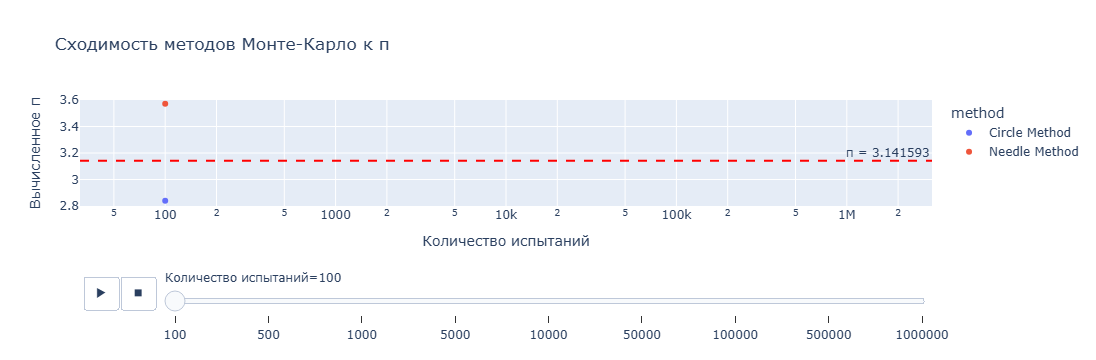

In [22]:
fig = px.scatter(
    df_results, 
    x='n', 
    y='pi_estimated',
    animation_frame='n',  
    color='method',
    range_y=[2.8, 3.6],
    log_x=True, 
    title='Сходимость методов Монте-Карло к π',
    labels={'n': 'Количество испытаний', 'pi_estimated': 'Вычисленное π'},
    hover_data=['error', 'relative_error']
)

fig.add_hline(y=np.pi, line_dash="dash", line_color="red",
              
              annotation_text=f"π = {np.pi:.6f}")
fig.update_xaxes(range=[np.log10(min(n_values)) - 0.5,
                       np.log10(max(n_values)) + 0.5])

fig.update_layout(
    showlegend=True,
    hovermode='x unified'
)

fig.show()